**TODO**

* compare visible tau 4-momentum between generator-level, reconstructed and sum of regressed constituents
  * distributions themselves, ~~their ratio (scale, resolution)~~ + correlation
  * also visible tau momentum at generator level vs the sum of generator-level constituents
* same as before but for DM 0 (single prong without any neutral pions)
* tau ID efficiency plot

In [1]:
import pandas as pd
import os.path

In [2]:
df = pd.read_parquet(os.path.expanduser('~/tmp/260916_ParTauDETR_pred.parquet'))

In [3]:
df.head()

,reco_jet_p4,gen_jet_p4,reco_cand_p4s,reco_cand_pdgs,reco_cand_charges,gen_jet_tau_vis_energy,gen_jet_tau_decaymode,gen_jet_tau_charge,gen_jet_tau_full_p4,gen_jet_tau_vis_daughter_p4s,gen_jet_tau_vis_daughter_pdgs,gen_jet_tau_vis_daughter_charges,gen_jet_tau_p4,pred_tau_daughter_meson_classes,pred_tau_daughter_p4s,pred_tau_daughter_charges,tau_decaymode,tau_p4,tau_charge,gen_jet_tau_decaymode_exp
0,"{'pt': 28.01141246226131, 'eta': 0.62594993037...","{'pt': 28.153107903361537, 'eta': 0.6261941075...","[{'pt': 5.355902671813965, 'eta': 0.5888699293...","[211, 211, 211]","[1.0, -1.0, -1.0]",33.873270,10,-1.0,"{'pt': 38.03519545080289, 'eta': 0.62177128643...","[{'pt': 11.50993178607006, 'eta': 0.6079446722...","[-211, -211, 211]","[-1.0, -1.0, 1.0]","{'pt': 28.153107903361537, 'eta': 0.6261941075...",[0],"[{'rho': 11.543214797973633, 'phi': -1.2921282...",[-1],0,"{'rho': 11.54321575164795, 'phi': -1.292128205...",-1,10
1,"{'pt': 33.711961466283675, 'eta': 0.0561190174...","{'pt': 37.870262860551556, 'eta': 0.0393549506...","[{'pt': 6.542594909667969, 'eta': 0.0129832811...","[211, 211, 130, 130, 130, 22]","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0]",37.740174,11,1.0,"{'pt': 44.47542908044899, 'eta': 0.02974934168...","[{'pt': 1.7280236876430668, 'eta': 0.080435231...","[111, 211, 211, -211]","[0.0, 1.0, 1.0, -1.0]","{'pt': 37.68743641302869, 'eta': 0.03986450361...","[0, 0]","[{'rho': 9.320657730102539, 'phi': -2.14491009...","[-1, 1]",5,"{'rho': 28.36518096923828, 'phi': -2.134957313...",0,11
2,"{'pt': 21.47006164302517, 'eta': 0.80450264946...","{'pt': 20.453849993411996, 'eta': 0.8044986719...","[{'pt': 3.5935041904449463, 'eta': 0.843456387...","[211, 130, 22, 22]","[-1.0, 0.0, 0.0, 0.0]",27.449100,1,-1.0,"{'pt': 33.02779795963855, 'eta': 0.82659275463...","[{'pt': 16.89733243315867, 'eta': 0.7958298258...","[111, -211]","[0.0, -1.0]","{'pt': 20.453852527257066, 'eta': 0.8044986709...",[1],"[{'rho': 17.743946075439453, 'phi': -2.9838635...",[0],-4,"{'rho': 17.743947982788086, 'phi': -2.98386359...",0,1
3,"{'pt': 18.61034503407158, 'eta': -0.4895068962...","{'pt': 18.13051461595269, 'eta': -0.4886871005...","[{'pt': 13.610233306884766, 'eta': -0.51128113...","[211, 22, 22]","[-1.0, 0.0, 0.0]",20.353977,1,-1.0,"{'pt': 39.9830573215418, 'eta': -0.52251526831...","[{'pt': 4.507004933011936, 'eta': -0.419670486...","[111, -211]","[0.0, -1.0]","{'pt': 18.130517652478378, 'eta': -0.488687089...","[1, 1, 0]","[{'rho': 4.857665538787842, 'phi': -1.37580180...","[0, 0, -1]",2,"{'rho': 23.3341007232666, 'phi': -1.3763170242...",-1,1
4,"{'pt': 0.33594428598124226, 'eta': -1.44753128...","{'pt': 0.3296147730742327, 'eta': -1.453719752...","[{'pt': 0.335944265127182, 'eta': -1.447531342...",[211],[-1.0],0.756709,0,-1.0,"{'pt': 13.797715577505697, 'eta': -1.775068965...","[{'pt': 0.3296147730742327, 'eta': -1.45371975...",[-211],[-1.0],"{'pt': 0.3296147730742327, 'eta': -1.453719752...",[0],"[{'rho': 0.3443812131881714, 'phi': 2.24982261...",[-1],0,"{'rho': 0.3443812429904938, 'phi': 2.249822616...",-1,0


For some reason, `gen_jet_tau_decaymode` and `gen_jet_tau_decaymode_exp` disagree in 0.5% of the cases.

In [4]:
sum(df['gen_jet_tau_decaymode'] != df['gen_jet_tau_decaymode_exp']) / sum(df['gen_jet_tau_decaymode'] == df['gen_jet_tau_decaymode_exp']) * 100

0.5035443739973767

Agreement in decay modes is not great. We can identify 90% of single pion decays as such, but only about half of the taus that we predict to be a single pion are in fact single pion.
In many single prong plus one or two neutral pions (DMs 1 and 2) decays, the single prong is misidentified as neutral, which is why most of them contribute to the "invalid" category.
The same holds true for 3-prong decays in which two of the three prongs are misidentified as neutral pions.

The main issue seems to be charge identification.

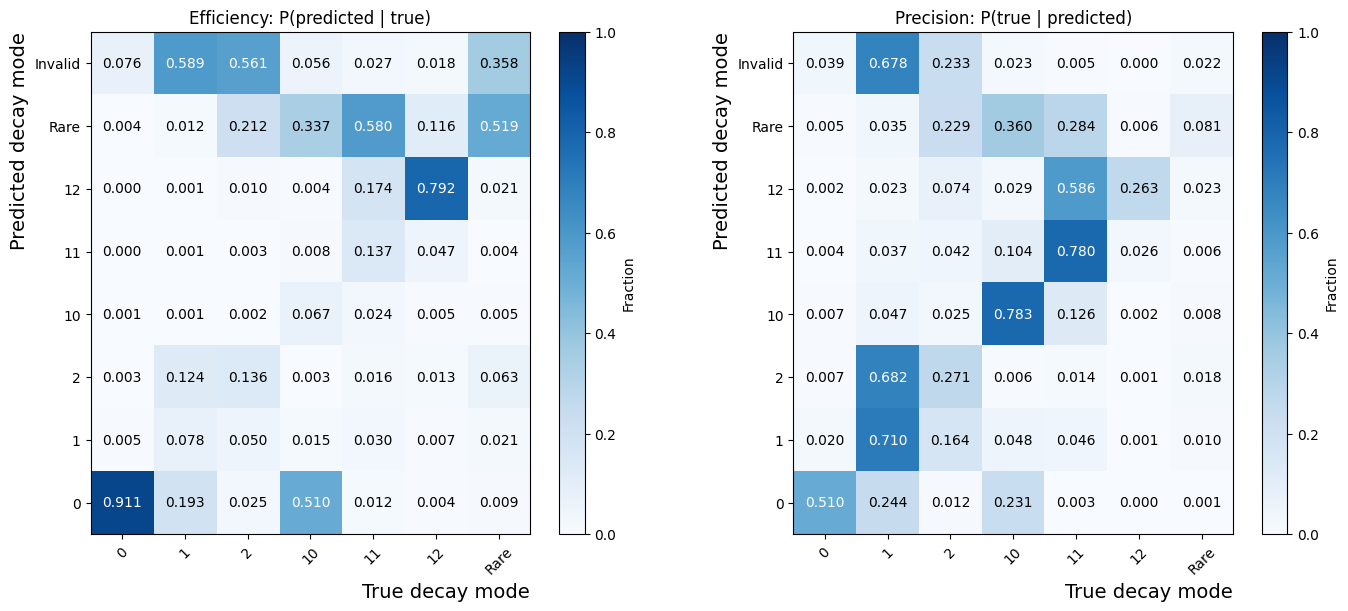

In [5]:
import matplotlib.pyplot as plt

explicit_dms = [0, 1, 2, 10, 11, 12]
labels = explicit_dms + ["Rare"]
predicted_labels = labels + ["Invalid"]


def normalize_truth_dm(dm):
    return dm if dm in explicit_dms else "Rare"


def predict_dm(class_array):
    n_charged = sum(class_value == 0 for class_value in class_array)
    n_neutral = sum(class_value == 1 for class_value in class_array)
    if n_charged == 0 or n_neutral > 4:
        return "Invalid"
    dm = 5 * (n_charged - 1) + n_neutral
    return dm if dm in explicit_dms else "Rare"


true_dm = df["gen_jet_tau_decaymode"].map(normalize_truth_dm)
predicted_dm = df["pred_tau_daughter_meson_classes"].map(predict_dm)

confusion_efficiency = pd.crosstab(
    predicted_dm,
    true_dm,
    normalize="columns",
).reindex(index=predicted_labels, columns=labels, fill_value=0).fillna(0)

confusion_precision = pd.crosstab(
    predicted_dm,
    true_dm,
    normalize="index",
).reindex(index=predicted_labels, columns=labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    ["Efficiency: P(predicted | true)", "Precision: P(true | predicted)"],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(labels)),
        xticklabels=labels,
        yticks=range(len(predicted_labels)),
        yticklabels=predicted_labels[::-1],
    )
    ax.set_xlabel("True decay mode", loc="right", fontsize=14)
    ax.set_ylabel("Predicted decay mode", loc="top", fontsize=14)
    ax.tick_params(axis="x", rotation=45)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")

plt.show()
plt.close()

The following plots confirm that the model is unable to predict the total charge correctly, as in close to half of the time the model predicts constituents whose charge sum equals zero.

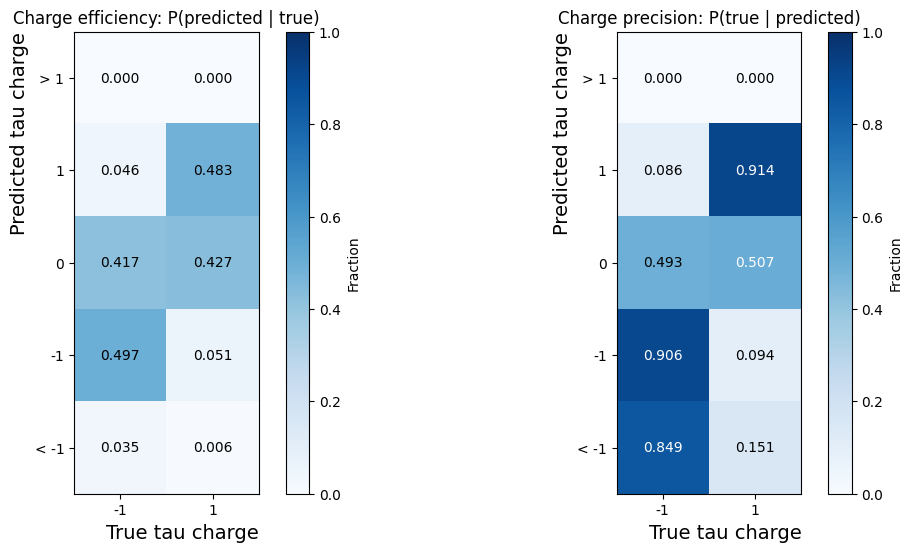

In [6]:
charge_labels = [-1, 1]
predicted_charge_labels = ["< -1", -1, 0, 1, "> 1"]


def predict_charge(charge_array):
    charge = sum(charge_array)
    if charge < -1:
        return "< -1"
    if charge > 1:
        return "> +1"
    return int(charge)


true_charge = df["gen_jet_tau_charge"].astype(int)
predicted_charge = df["pred_tau_daughter_charges"].map(predict_charge)
confusion_efficiency = pd.crosstab(
    predicted_charge,
    true_charge,
    normalize="columns",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)
confusion_precision = pd.crosstab(
    predicted_charge,
    true_charge,
    normalize="index",
).reindex(index=predicted_charge_labels, columns=charge_labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=False,
    gridspec_kw={"wspace": 0},
)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    ["Charge efficiency: P(predicted | true)", "Charge precision: P(true | predicted)"],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(charge_labels)),
        xticklabels=charge_labels,
        yticks=range(len(predicted_charge_labels)),
        yticklabels=predicted_charge_labels[::-1],
    )
    ax.set_xlabel("True tau charge", loc="right", fontsize=14)
    ax.set_ylabel("Predicted tau charge", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")
plt.show()
plt.close()

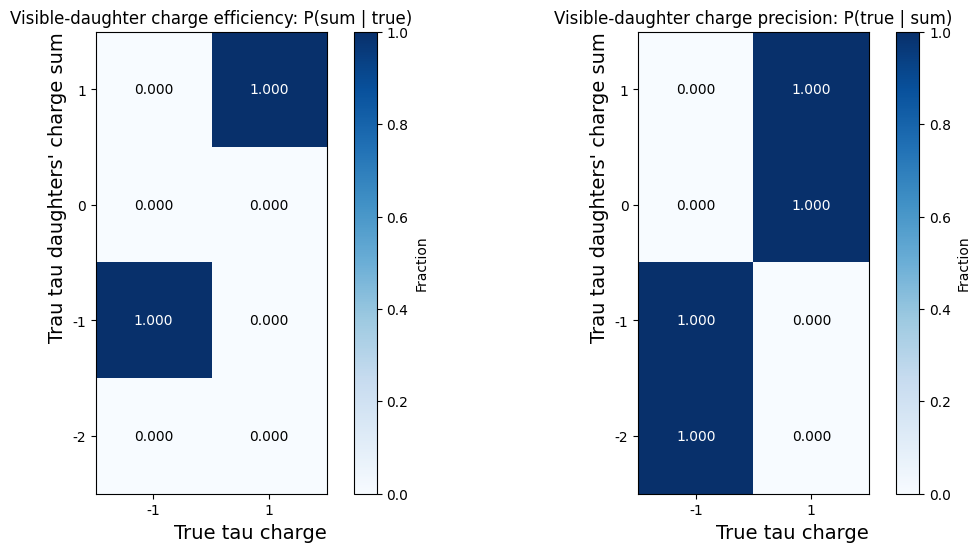

In [7]:
daughter_charge_labels = sorted(
    df["gen_jet_tau_vis_daughter_charges"].map(sum).astype(int).unique()
)


def sum_daughter_charge(charge_array):
    return int(sum(charge_array))


visible_daughter_charge = df["gen_jet_tau_vis_daughter_charges"].map(sum_daughter_charge)
confusion_efficiency = pd.crosstab(
    visible_daughter_charge,
    true_charge,
    normalize="columns",
).reindex(index=daughter_charge_labels, columns=charge_labels, fill_value=0).fillna(0)
confusion_precision = pd.crosstab(
    visible_daughter_charge,
    true_charge,
    normalize="index",
).reindex(index=daughter_charge_labels, columns=charge_labels, fill_value=0).fillna(0)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=False,
    gridspec_kw={"wspace": 0},
)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    [
        "Visible-daughter charge efficiency: P(sum | true)",
        "Visible-daughter charge precision: P(true | sum)",
    ],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(charge_labels)),
        xticklabels=charge_labels,
        yticks=range(len(daughter_charge_labels)),
        yticklabels=daughter_charge_labels[::-1],
    )
    ax.set_xlabel("True tau charge", loc="right", fontsize=14)
    ax.set_ylabel("Trau tau daughters' charge sum", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction")
plt.show()
plt.close()

In negligible subset of events the charge sum of generator-level tau daughters adds up to a value other than +1 or -1.

In [8]:
len(df[abs(df["gen_jet_tau_vis_daughter_charges"].map(sum_daughter_charge)) != 1]) / len(df)

7.616881039551924e-05

The model also tends to predict fewer objects than expected.

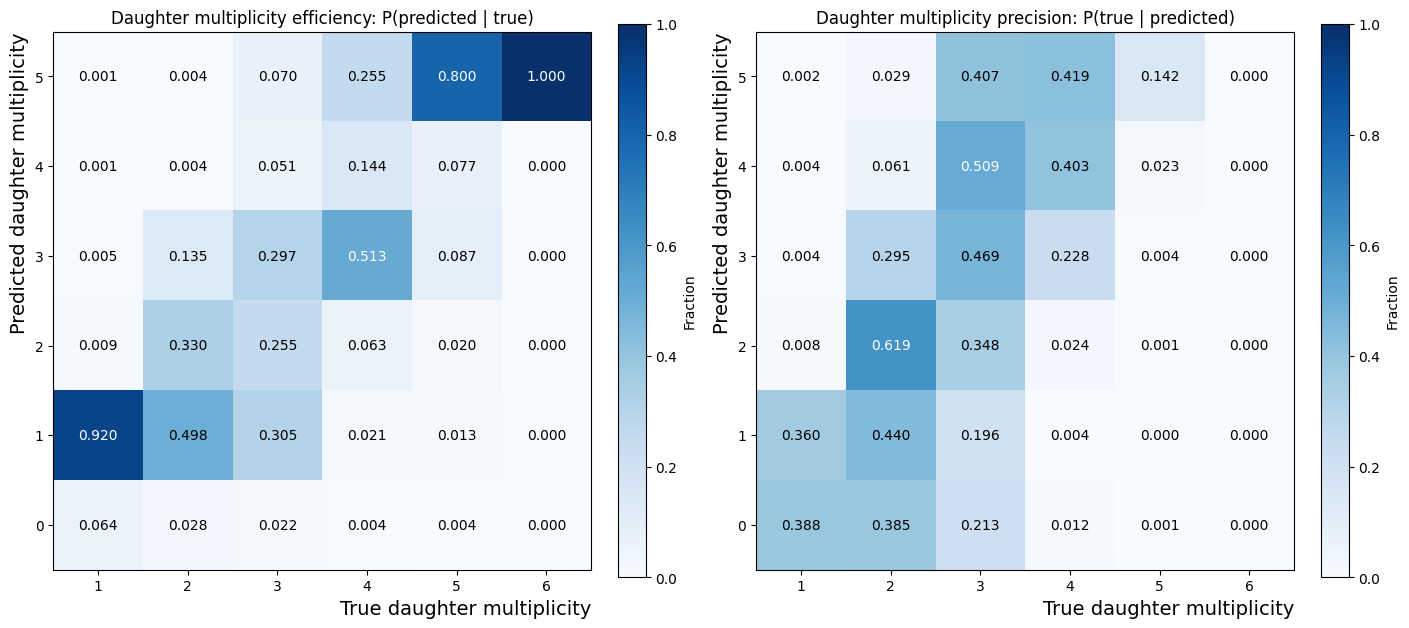

In [9]:
multiplicity_labels = sorted(df["gen_jet_tau_vis_daughter_pdgs"].map(len).unique())
predicted_multiplicity_labels = sorted(df["pred_tau_daughter_meson_classes"].map(len).unique())

true_multiplicity = df["gen_jet_tau_vis_daughter_pdgs"].map(len)
predicted_multiplicity = df["pred_tau_daughter_meson_classes"].map(len)
confusion_efficiency = pd.crosstab(
    predicted_multiplicity,
    true_multiplicity,
    normalize="columns",
).reindex(
    index=predicted_multiplicity_labels,
    columns=multiplicity_labels,
    fill_value=0,
).fillna(0)
confusion_precision = pd.crosstab(
    predicted_multiplicity,
    true_multiplicity,
    normalize="index",
).reindex(
    index=predicted_multiplicity_labels,
    columns=multiplicity_labels,
    fill_value=0,
).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    [confusion_efficiency, confusion_precision],
    [
        "Daughter multiplicity efficiency: P(predicted | true)",
        "Daughter multiplicity precision: P(true | predicted)",
    ],
):
    matrix = matrix.iloc[::-1]
    image = ax.imshow(matrix, vmin=0, vmax=1, cmap="Blues")
    ax.set(
        title=title,
        xticks=range(len(multiplicity_labels)),
        xticklabels=multiplicity_labels,
        yticks=range(len(predicted_multiplicity_labels)),
        yticklabels=predicted_multiplicity_labels[::-1],
    )
    ax.set_xlabel("True daughter multiplicity", loc="right", fontsize=14)
    ax.set_ylabel("Predicted daughter multiplicity", loc="top", fontsize=14)
    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            cell_value = matrix.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                f"{cell_value:.3f}",
                ha="center",
                va="center",
                color="white" if cell_value > 0.5 else "black",
            )
    fig.colorbar(image, ax=ax, label="Fraction", shrink = 0.8)
plt.show()
plt.close()

In [10]:
import awkward as ak
import numpy as np


n_events = -1
p4_sources = {
    "Generator visible tau": ("gen_jet_p4", False),
    "Generator daughters": ("gen_jet_tau_vis_daughter_p4s", True),
    "Reconstructed jet": ("reco_jet_p4", False),
    "Reconstructed constituents": ("reco_cand_p4s", True),
    "Predicted daughters": ("pred_tau_daughter_p4s", True),
}
quantity_units = {"pt": "GeV", "eta": "", "phi": "", "mass": "GeV"}
quantity_ranges = {"pt": (0, 45), "eta": (-2.7, 2.7), "phi": (-np.pi, np.pi), "mass": (0, 3)}
n_bins = 16


def subset_events(series):
    if n_events == -1:
        return series
    return series.iloc[:n_events]


def p4_components(p4_array, predicted=False):
    pt = p4_array["rho"] if predicted else p4_array["pt"]
    eta = p4_array["eta"]
    phi = p4_array["phi"]
    if predicted:
        mass = p4_array["tau"]
        energy = np.sqrt((pt * np.cosh(eta)) ** 2 + mass**2)
    else:
        energy = p4_array["energy"]
    return (
        pt * np.cos(phi),
        pt * np.sin(phi),
        pt * np.sinh(eta),
        energy,
    )


def summed_p4(p4_array, predicted=False):
    px, py, pz, energy = p4_components(p4_array, predicted=predicted)
    px = ak.sum(px, axis=1)
    py = ak.sum(py, axis=1)
    pz = ak.sum(pz, axis=1)
    energy = ak.sum(energy, axis=1)
    pt = np.hypot(px, py)
    eta = np.arcsinh(ak.where(pt != 0, pz / pt, 0))
    phi = np.arctan2(py, px)
    mass_squared = energy**2 - px**2 - py**2 - pz**2
    mass = np.sqrt(np.maximum(mass_squared, 0))
    return {"pt": pt, "eta": eta, "phi": phi, "mass": mass}


def histogram_with_uncertainty(values, bins):
    counts, _ = np.histogram(values, bins=bins)
    total = counts.sum()
    fractions = counts / total if total else np.zeros_like(counts, dtype=float)
    uncertainties = np.sqrt(counts) / total if total else np.zeros_like(counts, dtype=float)
    return fractions, uncertainties


def plot_quantity(quantity):
    values = {
        source_name: source_quantity(field, quantity, is_array)
        for source_name, (field, is_array) in p4_sources.items()
    }
    generator_values = values["Generator visible tau"]
    bins = np.linspace(*quantity_ranges[quantity], n_bins + 1)

    distributions = {}
    uncertainties = {}
    for source_name, source_values in values.items():
        distributions[source_name], uncertainties[source_name] = histogram_with_uncertainty(
            source_values,
            bins,
        )

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    source_colors = {
        source_name: colors[index % len(colors)]
        for index, source_name in enumerate(p4_sources)
    }
    centers = 0.5 * (bins[1:] + bins[:-1])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for source_name in p4_sources:
        color = source_colors[source_name]
        axes[0].stairs(
            distributions[source_name],
            bins,
            label=source_name,
            linewidth=1.5,
            color=color,
        )
        axes[0].errorbar(
            centers,
            distributions[source_name],
            yerr=uncertainties[source_name],
            fmt="none",
            capsize=2,
            alpha=0.5,
            color=color,
        )

    generator_distribution = distributions["Generator visible tau"]
    generator_uncertainty = uncertainties["Generator visible tau"]
    for source_name in list(p4_sources)[1:]:
        color = source_colors[source_name]
        ratio = np.divide(
            distributions[source_name],
            generator_distribution,
            out=np.full_like(generator_distribution, np.nan),
            where=generator_distribution > 0,
        )
        ratio_uncertainty = ratio * np.sqrt(
            np.divide(
                uncertainties[source_name] ** 2,
                distributions[source_name] ** 2,
                out=np.zeros_like(ratio),
                where=distributions[source_name] > 0,
            )
            + np.divide(
                generator_uncertainty**2,
                generator_distribution**2,
                out=np.zeros_like(ratio),
                where=generator_distribution > 0,
            )
        )
        axes[1].plot(
            centers,
            ratio,
            marker="o",
            markersize=3,
            label=source_name,
            color=color,
        )
        axes[1].errorbar(
            centers,
            ratio,
            yerr=ratio_uncertainty,
            fmt="none",
            capsize=2,
            color=color,
        )

    for source_name in ["Reconstructed jet", "Predicted daughters"]:
        color = source_colors[source_name]
        relative_values = values[source_name] / generator_values
        mask = np.isfinite(relative_values)
        spread = []
        spread_uncertainty = []
        for lower_edge, upper_edge in zip(bins[:-1], bins[1:]):
            bin_values = relative_values[
                mask & (generator_values >= lower_edge) & (generator_values < upper_edge)
            ]
            if len(bin_values) < 2:
                spread.append(np.nan)
                spread_uncertainty.append(np.nan)
                continue
            median = np.median(bin_values)
            spread_value = (np.percentile(bin_values, 75) - np.percentile(bin_values, 25)) / median
            spread.append(spread_value)
            spread_uncertainty.append(spread_value / np.sqrt(len(bin_values)))
        axes[2].plot(
            centers,
            spread,
            marker="o",
            markersize=3,
            label=source_name,
            color=color,
        )
        axes[2].errorbar(
            centers,
            spread,
            yerr=spread_uncertainty,
            fmt="none",
            capsize=2,
            color=color,
        )

    unit = f" [{quantity_units[quantity]}]" if quantity_units[quantity] else ""
    axes[0].set_title(f"{quantity} distribution")
    axes[1].set_title(f"{quantity} ratio to generator")
    axes[2].set_title(f"{quantity} relative spread")
    axes[0].set_ylabel(f"Normalized {quantity}{unit}")
    axes[1].set_ylabel("Ratio to generator")
    axes[2].set_ylabel("IQR / median")
    for ax in axes:
        ax.set_xlabel(f"Generator visible tau {quantity}{unit}")
        ax.grid(alpha=0.2)
    axes[1].axhline(1.0, color="black", linewidth=1, linestyle="--")
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    axes[2].legend(fontsize=8)
    for axes_idx in range(3):
      axes[axes_idx].set_xlim(bins[0], bins[-1])
    plt.show()
    plt.close()

In [11]:
def source_quantity(field, quantity, is_array):
    values = subset_events(df[field])
    predicted = field == "pred_tau_daughter_p4s"
    if is_array:
        summed = summed_p4(ak.Array(values.tolist()), predicted=predicted)
        return np.asarray(ak.to_numpy(summed[quantity]))

    result = []
    for record in values:
        pt = float(record["pt"])
        eta = float(record["eta"])
        phi = float(record["phi"])
        if quantity == "mass":
            energy = float(record["energy"])
            value = np.sqrt(max(energy**2 - (pt * np.cosh(eta)) ** 2, 0.0))
        else:
            value = {"pt": pt, "eta": eta, "phi": phi}[quantity]
        result.append(value)
    return np.asarray(result)

/opt/conda/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


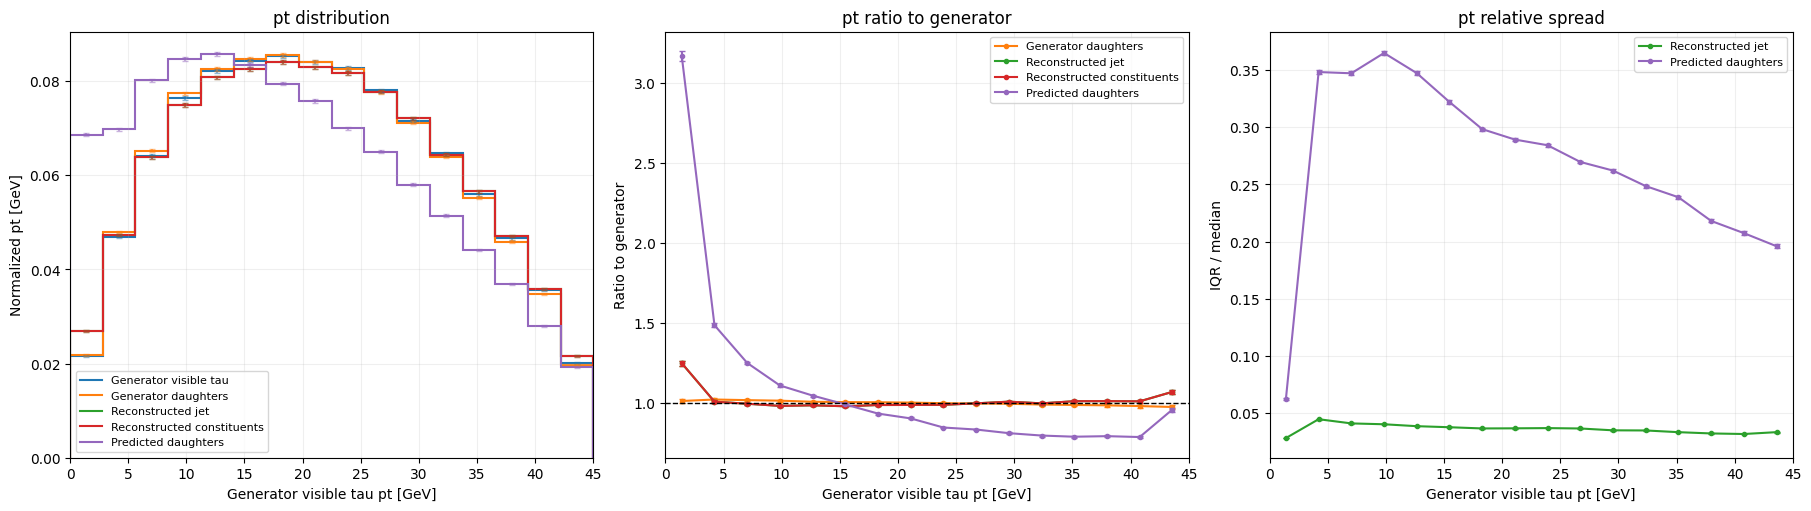

In [12]:
plot_quantity("pt")

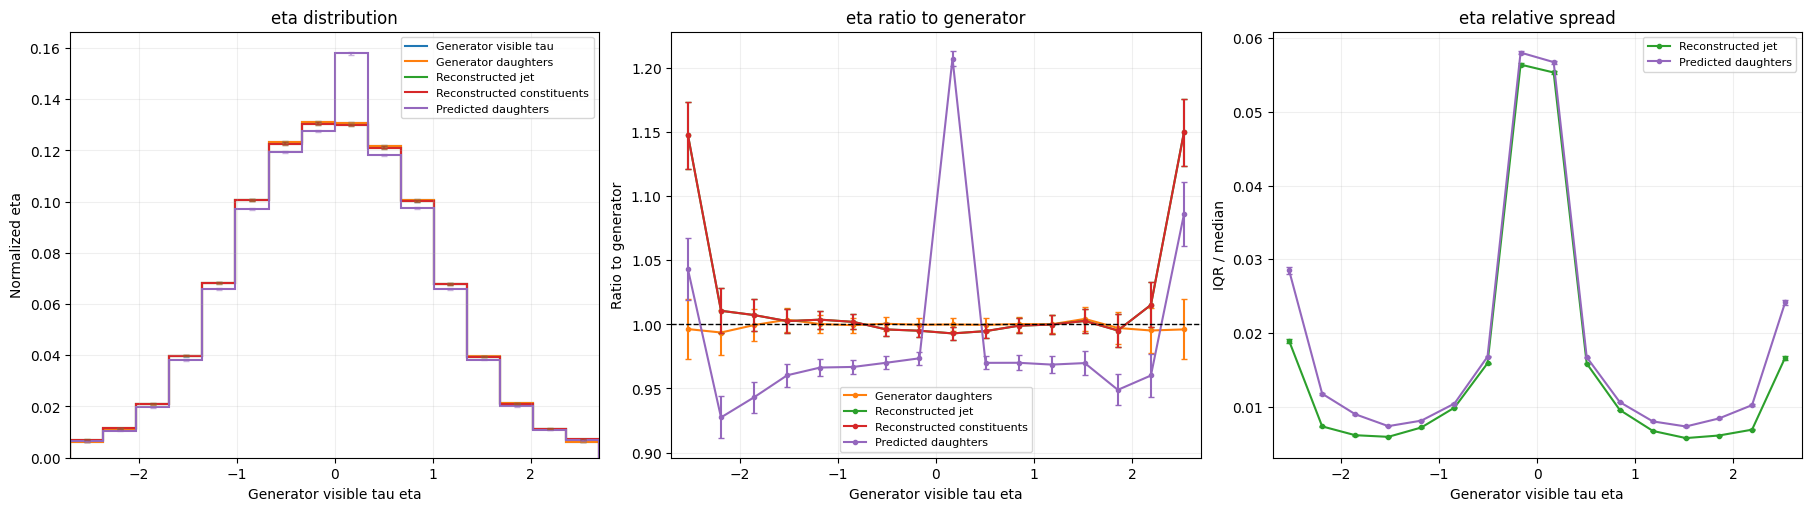

In [13]:
plot_quantity("eta")

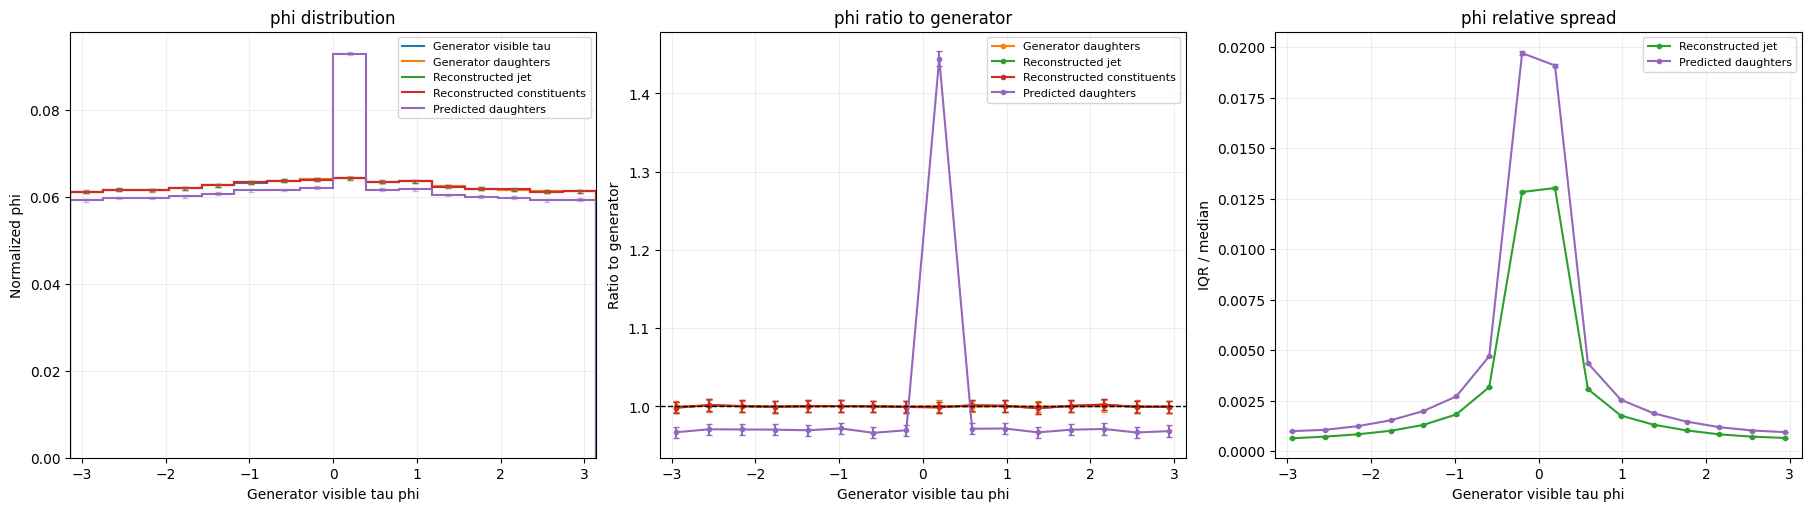

In [14]:
plot_quantity("phi")

/tmp/ipykernel_1042354/287223571.py:148: RuntimeWarning: divide by zero encountered in divide
  relative_values = values[source_name] / generator_values
/tmp/ipykernel_1042354/287223571.py:148: RuntimeWarning: invalid value encountered in divide
  relative_values = values[source_name] / generator_values


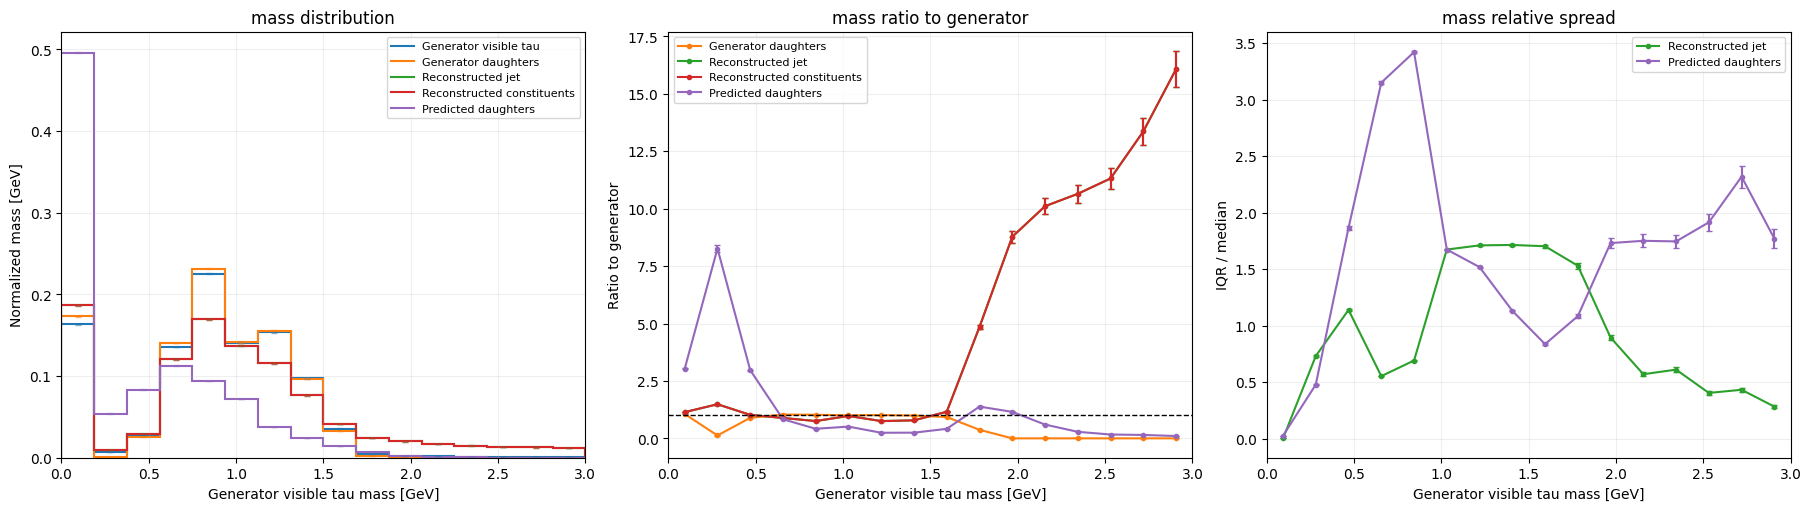

In [15]:
plot_quantity("mass")